In [76]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt

matplotlib.rcParams['date.converter'] = 'concise'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.size'] = 10


In [77]:
cryptic_detects = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')

# filter sample
cryptic_detects = cryptic_detects[cryptic_detects['sample'] != '11.29.23.PLNOV26.R1.rerun__NA__NA__231207_WW__00X']

cryptic_detects['collection_date'] = pd.to_datetime(cryptic_detects['collection_date'])
cryptic_detects = cryptic_detects[cryptic_detects['num_clinical_detections'] <=10]
cryptic_detects['len_mutations'] = cryptic_detects['nt_mutations'].apply(lambda x:len(x.split(' ')))
cryptic_detects = cryptic_detects[cryptic_detects['len_mutations'] > 1]
cryptic_detects = cryptic_detects[
    (cryptic_detects['coverage_start'] >= 21563) &
    (cryptic_detects['coverage_end'] <= 25384)
]


cryptic_detects = cryptic_detects.groupby('nt_mutations').agg(
    first_collection_date = ('collection_date', 'min'),
    last_collection_date = ('collection_date', 'max'),
    num_wastewater_detections = ('collection_date', 'count')
)
cryptic_detects = cryptic_detects[cryptic_detects['num_wastewater_detections'] > 3]



cryptic_detects['span_days'] = (cryptic_detects['last_collection_date'] - cryptic_detects['first_collection_date']).dt.days + 1
#cryptic_detects = cryptic_detects[cryptic_detects['span_days'] > 1]


# calculate the percentage of cryptic variants with span_days <= X
def calculate_percentage_within_span(cryptic_detects, max_span):
    total_cryptic_variants = len(cryptic_detects)
    variants_within_span = len(cryptic_detects[cryptic_detects['span_days'] <= max_span])
    percentage_within_span = (variants_within_span / total_cryptic_variants) * 100
    return percentage_within_span

# calculate percentages for num_wastewater_detections <= 10, 20, 30, 40
def calculate_percentage_within_detects(cryptic_detects, max_detects):
    total_cryptic_variants = len(cryptic_detects)
    variants_within_detects = len(cryptic_detects[cryptic_detects['num_wastewater_detections'] <= max_detects])
    percentage_within_detects = (variants_within_detects / total_cryptic_variants) * 100
    return percentage_within_detects


for span in [50, 100, 150, 200, 400, 500, 600]:
    percentage = calculate_percentage_within_span(cryptic_detects, span)
    print(f"Percentage of cryptic variants with span_days <= {span}: {percentage:.2f}%")

for detects in [10, 20, 30, 40, 50]:
    percentage = calculate_percentage_within_detects(cryptic_detects, detects)
    print(f"Percentage of cryptic variants with num_wastewater_detections <= {detects}: {percentage:.2f}%")

Percentage of cryptic variants with span_days <= 50: 13.34%
Percentage of cryptic variants with span_days <= 100: 25.49%
Percentage of cryptic variants with span_days <= 150: 40.80%
Percentage of cryptic variants with span_days <= 200: 46.19%
Percentage of cryptic variants with span_days <= 400: 82.98%
Percentage of cryptic variants with span_days <= 500: 97.95%
Percentage of cryptic variants with span_days <= 600: 99.66%
Percentage of cryptic variants with num_wastewater_detections <= 10: 48.42%
Percentage of cryptic variants with num_wastewater_detections <= 20: 60.65%
Percentage of cryptic variants with num_wastewater_detections <= 30: 66.21%
Percentage of cryptic variants with num_wastewater_detections <= 40: 71.43%
Percentage of cryptic variants with num_wastewater_detections <= 50: 76.22%


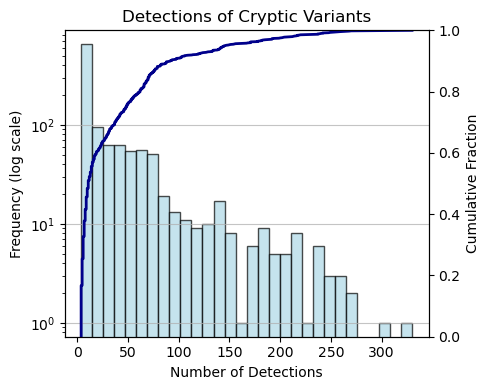

In [78]:
# Histogram of number of detections with cumulative distribution
fig, ax1 = plt.subplots(figsize=(5, 4))

# Histogram
ax1.hist(cryptic_detects['num_wastewater_detections'], bins=30, color='lightblue', edgecolor='black', alpha=0.7)
ax1.set_yscale('log')
ax1.set_xlabel('Number of Detections')
ax1.set_ylabel('Frequency (log scale)')
ax1.set_title('Detections of Cryptic Variants')
ax1.grid(axis='y', alpha=0.75)

# Twin axes for cumulative distribution
ax2 = ax1.twinx()
sorted_detections = cryptic_detects['num_wastewater_detections'].sort_values()
cumulative_detections = range(1, len(sorted_detections) + 1)

# Normalize cumulative count to 0-1 scale
cumulative_proportion = [x / len(sorted_detections) for x in cumulative_detections]
ax2.plot(sorted_detections, cumulative_proportion, color='darkblue', linewidth=2, label='Cumulative')
ax2.set_ylabel('Cumulative Fraction')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('distribution_of_num_detects.pdf', bbox_inches='tight', dpi=300, transparent=True)

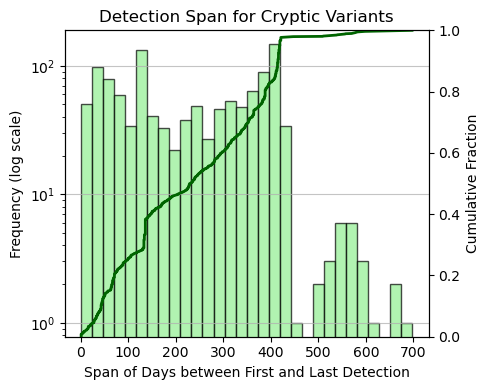

In [79]:
# Histogram of number of detections with cumulative distribution
fig, ax1 = plt.subplots(figsize=(5, 4))

# Histogram
ax1.hist(cryptic_detects['span_days'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
ax1.set_yscale('log')
ax1.set_xlabel('Span of Days between First and Last Detection')
ax1.set_ylabel('Frequency (log scale)')
ax1.set_title('Detection Span for Cryptic Variants')
ax1.grid(axis='y', alpha=0.75)

# Twin axes for cumulative distribution
ax2 = ax1.twinx()
sorted_detections = cryptic_detects['span_days'].sort_values()
cumulative_detections = range(1, len(sorted_detections) + 1)
# Normalize cumulative count to 0-1 scale
cumulative_proportion = [x / len(sorted_detections) for x in cumulative_detections]
ax2.plot(sorted_detections, cumulative_proportion, color='darkgreen', linewidth=2, label='Cumulative')
ax2.set_ylabel('Cumulative Fraction')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('distribution_of_span_days.pdf', bbox_inches='tight', dpi=300, transparent=True)